# Joint flow test

In [ ]:
import sys
sys.path.append('..')  

import discovery as ds
import discovery.flow as dsf
from flowjax.flows import masked_autoregressive_flow, coupling_flow
from flowjax.distributions import StandardNormal
import pandas as pd
import numpy as np
import jax
import matplotlib.pyplot as plt
import jax.numpy as jnp
import jax.scipy as jsp
from fourierpta import *
from numpyro import infer

C:\Users\amirt\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
npsr = 1
feathers = pathlib.Path(ds.__path__[0] + '/../../data/')

allpsrs = sorted(
    [ds.Pulsar.read_feather(psrfile) for psrfile in list(feathers.glob("*-[JB]*.feather"))],
    key=lambda psr: len(psr.toas), reverse = True
)


In [ ]:
psrs = allpsrs[:npsr]
Tspan = ds.getspan(psrs)

In [ ]:
rn_components = 30
gw_components = 14
powerlaw = ds.powerlaw
rn_init_params =  extract_rn_params(psrs)
N = 10000
ecorr = False 
fixed_wn = True

# Creating the HD Fourier model
pslmodels = fouriermodel(psrs, rn_components, 
                                 rn_init_params= {}, ecorr = ecorr, 
                                 powerlaw = powerlaw, fixed_wn = fixed_wn)


In [ ]:
ds.priordict_standard
newdict = {'(.*_)?red_noise_coefficients\\(([0-9]*)\\)': [-100, 100]} # just much broader than we'll encounter

In [ ]:
import re
def simple_dict_transformation(func,priordict=newdict):
    """change from dictionary as input to list of arrays as input

    Parameters
    ----------
    func : discovery likelihood
        discovery likelihood function
    """
    priordict = {**ds.priordict_standard, **priordict}

    # figure out slices when there are vector arguments
    slices, offset = [], 0

    for par in func.params:
        if '(' in par:
            l = int(par[par.index('(')+1:par.index(')')]) if '(' in par else 1
            slices.append(slice(offset, offset+l))
            offset = offset + l
        else:
            slices.append(offset)
            offset = offset + 1
    # build vectors of DF column names and of lower and upper uniform limits
    a, b = [], []
    columns = []
    for par, slice_ in zip(func.params, slices):
        for pname, prange in priordict.items():
            if re.match(pname, par):
                therange = prange
                break
        else:
            raise KeyError(f"No known prior for {par}.")

        if '(' in par:
            root = par[:par.index('(')]
            l = int(par[par.index('(')+1:par.index(')')]) if '(' in par else 1

            for i in range(l):
                columns.append(f'{root}[{i}]')
                a.append(therange[0])
                b.append(therange[1])
        else:
            columns.append(par)
            a.append(therange[0])
            b.append(therange[1])
    a, b = ds.matrix.jnparray(a), ds.matrix.jnparray(b)

    def to_dict_and_jacobian(ys, ahat, L):
        # format is typically (wnps, rn coeffs, rn hyperparams),
        # this is the assumed format in what follows
        # should work for all psrs but could prb be more general
        # without assuming specific order of params
    
        hyper_pars = [p for p in func.params if "coefficients" not in p]
        coeff_pars = [p for p in func.params if "coefficients" in p]
        
        n_theta = sum(1 for p in hyper_pars if "red_noise" not in p)
        n_eta = len(hyper_pars) - n_theta
        len_hyper = len(hyper_pars)

        ys_theta = ys[:n_theta]
        ys_eta   = ys[slices[func.params.index(coeff_pars[0])].stop:]  # after coefficients
        ys_hyper = jnp.concatenate([ys_theta, ys_eta])

        a_hyper_combined = jnp.concatenate([a[:n_theta], a[n_theta+len(ys)-len_hyper:]])
        b_hyper_combined = jnp.concatenate([b[:n_theta], b[n_theta+len(ys)-len_hyper:]])

        if len_hyper > 0:
            xs_hyper = 0.5 * (b_hyper_combined + a_hyper_combined +
                            (b_hyper_combined - a_hyper_combined) * jnp.tanh(ys_hyper))
            hyper_jacobian = jnp.sum(jnp.log(2.0) - 2.0 * jnp.logaddexp(ys_hyper, -ys_hyper))
            hyper_dict = dict(zip(hyper_pars, jnp.array(xs_hyper).T))
        else:
            hyper_jacobian = 0.0
            hyper_dict = {}

        jac = jnp.sum(jnp.log(jnp.diag(L)))
        coeff_idx = func.params.index(coeff_pars[0])
        xs_coeff  = L @ ys[slices[coeff_idx]] + ahat  
        hyper_dict.update({coeff_pars[0]: xs_coeff})

        return hyper_dict, jac + hyper_jacobian

        
    def transformed(ys, ahat, L):
        mydict, jac = to_dict_and_jacobian(ys, ahat, L)
        return func(mydict) + jac
    
    transformed.params = func.params
    transformed.to_dict_and_jacobian = to_dict_and_jacobian
    transformed.a_bounds = a
    transformed.b_bounds = b
    transformed.columns = columns
    
    return transformed

In [ ]:
logxs = [simple_dict_transformation(pslmodels[_].clogL) for _ in range(npsr)]

In [ ]:
logL_test  = logxs[0]

hyper_pars = [p for p in logL_test.params if "coefficients" not in p]
hyper_indices = jnp.array([logL_test.columns.index(p) for p in hyper_pars])
a_hyper = logL_test.a_bounds[hyper_indices]
b_hyper = logL_test.b_bounds[hyper_indices]

def get_bounds(p):
    # not very optimal but keep it for now...
    if "efac" in p:
        return 0.9, 1.1
    elif "red_noise_gamma" in p:
        return 0.0, 7.0
    elif "red_noise_log10_A" in p:
        return -20.0, -11.0
    else:
        return -8.5, -5.0 

low  = jnp.array([get_bounds(p)[0] for p in hyper_pars])
high = jnp.array([get_bounds(p)[1] for p in hyper_pars])

In [ ]:
def fit_flow_joint(logx, psr_model, num_samples, num_params, rng,
                          hyper_pars, a_hyper, b_hyper):
    n_hyper = len(hyper_pars)
    n_coeff = num_params - n_hyper

    def logx_conditional(ys):
        y_hyper = ys[n_coeff:]

        xs_hyper = 0.5 * (b_hyper + a_hyper + (b_hyper - a_hyper) * jnp.tanh(y_hyper))
        eta_dict = dict(zip(hyper_pars, xs_hyper))

        ahat_eta, cf_inv_eta = psr_model.conditional(eta_dict)
        sigma_eta = jsp.linalg.cho_solve((cf_inv_eta[0], True), 
                                         jnp.eye(cf_inv_eta[0].shape[0]))
        L_eta = jsp.linalg.cholesky(sigma_eta, lower=True)
        return logx(ys, ahat_eta, L_eta)

    key, sample_key, flow_key, train_key = jax.random.split(rng, 4)
    
    def logx_normalized(ys):
        return logx_conditional(ys) 

    loss = dsf.value_and_grad_ElboLoss(
               logx_normalized, num_samples=num_samples)

    flow = masked_autoregressive_flow(
        flow_key, base_dist=StandardNormal((num_params,)),
        flow_layers=2, nn_width=16, nn_depth=4,
        invert=True)
    
    trainer = dsf.VariationalFit(
        dist=flow, loss_fn=loss, multibatch=1,
        learning_rate=1e-2,
        annealing_schedule=lambda i: min(1.0, 0.5 + 0.5*i/25),
        show_progress=True)
    
    train_key, trained_flow = trainer.run(train_key, steps=1001)
    return train_key, trained_flow, trainer

logL_test = logxs[0]
hyper_pars = [p for p in logL_test.params if "coefficients" not in p]
hyper_indices = jnp.array([logL_test.columns.index(p) for p in hyper_pars])
a_hyper = logL_test.a_bounds[hyper_indices]
b_hyper = logL_test.b_bounds[hyper_indices]

num_samples = 32
rng = jax.random.key(0)

trained_flows = []
train_keys = []
for i in range(npsr):
    print(f"Fitting flow for pulsar {pslmodels[i].name}")
    num_params = 2*rn_components + len(hyper_pars)
    train_key, trained_flow, trainer = fit_flow_joint(
        logxs[i], pslmodels[i],
        num_samples, num_params, rng,
        hyper_pars, a_hyper, b_hyper,
    )
    trained_flows.append(trained_flow)
    train_keys.append(train_key)

Fitting flow for pulsar J1713+0747


 46%|████▌     | 458/1001 [01:14<01:28,  6.13it/s, loss=-803271.44]

Early stopping at iteration 458


In [ ]:
import numpyro
import numpyro.distributions as dist


In [ ]:
pslmodels = fouriermodel(psrs, rn_components,
                         rn_init_params={}, ecorr=ecorr,
                         powerlaw=powerlaw, fixed_wn=fixed_wn)
logxs = [simple_dict_transformation(pslmodels[_].clogL) for _ in range(npsr)]
logL_test = logxs[0]

def model_test():
    etas = {}
    for p in hyper_pars:
        if "log10" in p:
            etas[p] = numpyro.sample(p, dist.Uniform(-20, -11))
        else:
            etas[p] = numpyro.sample(p, dist.Uniform(0, 7))

    xs_hyper = jnp.array([etas[p] for p in hyper_pars])
    y_hyper  = jnp.arctanh((2.0 * xs_hyper - b_hyper - a_hyper) / (b_hyper - a_hyper))

    xi = numpyro.sample("xi", dist.Normal(jnp.zeros(60), jnp.ones(60)))
    # using ahat and cf_inv_eta based on eta and not on eta_0
    ahat_eta, cf_inv_eta = pslmodels[0].conditional(etas)
    sigma_eta = jsp.linalg.cho_solve(
                    (cf_inv_eta[0], True), jnp.eye(cf_inv_eta[0].shape[0]))
    L_eta     = jsp.linalg.cholesky(sigma_eta, lower=True)

    numpyro.deterministic("a", ahat_eta + L_eta @ xi)
    ys = jnp.concatenate([xi, y_hyper])

    loglik = logL_test(ys, ahat_eta, L_eta) + 0.5 * jnp.dot(xi, xi)
    numpyro.factor("logL", loglik)

kernel  = infer.NUTS(model_test)
sampler = infer.MCMC(kernel, num_warmup=1000, num_samples=4000, progress_bar=True)

init_params = {"xi": jnp.zeros(60)}
for p in hyper_pars:
    if "log10" in p:
        init_params[p] = float(rn_init_params[0]['log10_A'])
    else:
        init_params[p] = float(rn_init_params[0]['gamma'])

sampler.run(jax.random.key(0), init_params=init_params)
samples = sampler.get_samples()
sampler.print_summary()

sample: 100%|██████████| 5000/5000 [02:43<00:00, 30.50it/s, 7 steps of size 4.84e-01. acc. prob=0.86]  



                                    mean       std    median      5.0%     95.0%     n_eff     r_hat
    J1713+0747_red_noise_gamma      1.75      0.28      1.73      1.31      2.23   3988.66      1.00
  J1713+0747_red_noise_log10_A    -13.60      0.07    -13.60    -13.71    -13.50   4485.00      1.00
                         xi[0]      0.00      1.00      0.01     -1.70      1.56   6748.48      1.00
                         xi[1]      0.00      0.98      0.00     -1.55      1.64   6260.92      1.00
                         xi[2]     -0.00      1.01     -0.00     -1.52      1.80   6046.37      1.00
                         xi[3]      0.01      1.01      0.00     -1.56      1.71   5421.89      1.00
                         xi[4]      0.00      0.98     -0.01     -1.61      1.60   6221.04      1.00
                         xi[5]      0.01      1.04      0.01     -1.66      1.72   5551.33      1.00
                         xi[6]      0.00      0.99      0.00     -1.71      1.54   4877.06

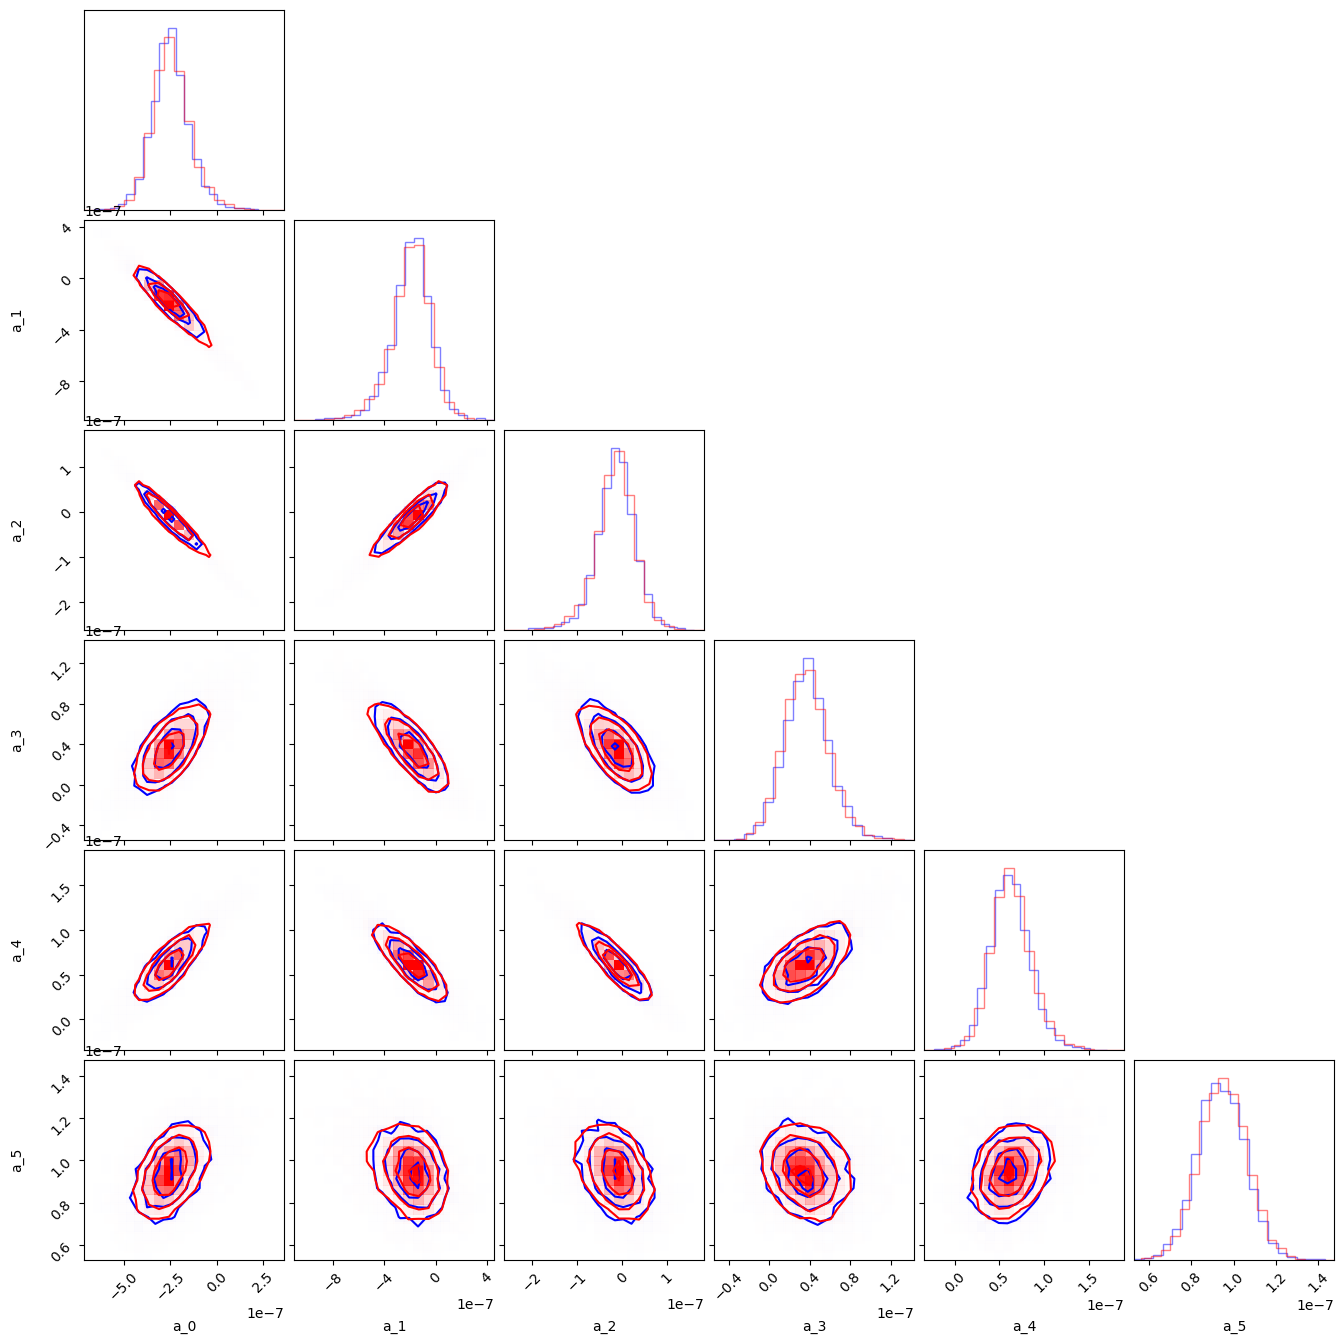

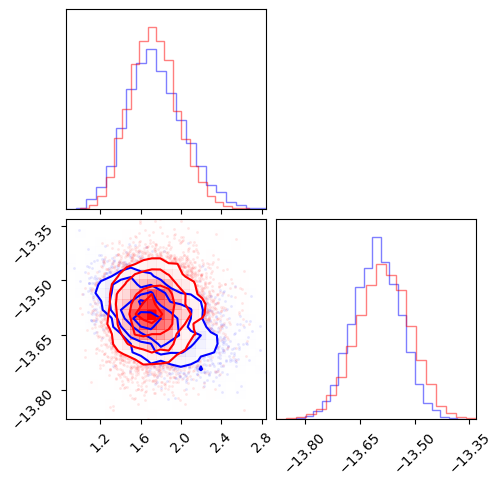

In [ ]:
trained_flow = trained_flows[0]

samples_ys   = trained_flow.sample(train_keys[0], sample_shape=(10000,)) 
n_hyper = 2
n_coeff = 2*rn_components
def flow_sample_to_a_and_hypers(ys):
    xi = ys[:n_coeff]
    y_hyper = ys[n_coeff:]

    xs_hyper = 0.5 * (b_hyper + a_hyper + (b_hyper - a_hyper) * jnp.tanh(y_hyper))
    eta_dict = dict(zip(hyper_pars, xs_hyper))

    ahat_eta, cf_inv_eta = pslmodels[0].conditional(eta_dict)
    sigma_eta = jsp.linalg.cho_solve((cf_inv_eta[0], True), jnp.eye(cf_inv_eta[0].shape[0]))
    L_eta = jsp.linalg.cholesky(sigma_eta, lower=True)
    a = ahat_eta + L_eta @ xi

    return a, xs_hyper

a_flow, hypers_flow = jax.vmap(flow_sample_to_a_and_hypers)(samples_ys)
flow_vals = np.array(a_flow)                                            
flow_hypers = np.array(hypers_flow)                                       
mcmc_a = np.array(samples["a"])
mcmc_hypers = np.column_stack([np.array(samples[p]) for p in hyper_pars]) 

n_base = 0
n_show = 6
labels_a = [f"a_{n_base + i}" for i in range(n_show)]

fig1 = corner.corner(mcmc_a[:, n_base:n_base+n_show], labels=labels_a, color="blue",
                     plot_datapoints=False, hist_kwargs={"density": True, "alpha": 0.5, "color": "blue"})
corner.corner(flow_vals[:, n_base:n_base+n_show], labels=labels_a, color="red", fig=fig1,
              plot_datapoints=False, hist_kwargs={"density": True, "alpha": 0.5, "color": "red"})

plt.show()

fig2 = corner.corner(mcmc_hypers, color="blue", hist_kwargs={"density": True, "alpha": 0.5, "color": "blue"})
corner.corner(flow_hypers, color="red", fig=fig2, hist_kwargs={"density": True, "alpha": 0.5, "color": "red"})
plt.show()

In [ ]:
eta_samples = jnp.column_stack([jnp.array(samples[p]) for p in hyper_pars])

In [ ]:
from flowjax.train import fit_to_data
from flowjax.flows import masked_autoregressive_flow
from flowjax.distributions import StandardNormal
from flowjax.bijections import Affine

xi_samples  = jnp.array(samples["xi"])
eta_samples = jnp.column_stack([jnp.array(samples[p]) for p in hyper_pars])
n_coeff = xi_samples.shape[1]
n_hyper = eta_samples.shape[1]

key, flow_key1, flow_key2, train_key1, train_key2 = jax.random.split(jax.random.key(1), 5)

flow_cond = masked_autoregressive_flow(
    flow_key1, base_dist=StandardNormal((n_coeff,)),
    cond_dim=n_hyper,
    flow_layers=4, nn_width=32, nn_depth=4,
    invert=True,)

trained_flow_cond, train_key1 = fit_to_data(
    train_key1, dist=flow_cond,
    data=(xi_samples, eta_samples),   
    learning_rate=1e-3,
    max_epochs=1000,
    batch_size=256, )

  1%|          | 10/1000 [00:05<09:41,  1.70it/s, train=85.1, val=84.8 (Max patience reached)]
